In [77]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [78]:
df = pd.read_csv('/content/insurance.csv')

In [90]:
df.sample(5)

,age,sex,bmi,children,smoker,region,charges,lifestyle_risk
349,19,male,27.835,0,no,northwest,1635.73365,low
679,49,female,23.180,2,no,northwest,10156.78320,low
921,62,female,33.200,0,no,southwest,13462.52000,medium
683,53,male,24.320,0,no,northwest,9863.47180,medium
1122,53,female,36.860,3,yes,northwest,46661.44240,medium


In [80]:
def lifestyle_risk(row):
    if row['smoker'] == 'yes' and row['age'] >= 60:
        return 'high'
    if row['smoker'] == 'yes' or row['age'] >= 50:
        return 'medium'
    else:
        return 'low'

In [81]:
df['lifestyle_risk'] = df.apply(lifestyle_risk, axis=1)

In [82]:
X = df.drop(columns=['charges'], axis=1)
y = df['charges']

In [83]:
categorical_features = ['lifestyle_risk','smoker','sex', 'region']
numerical_features = ['age','bmi', 'children']

In [84]:
preprocessor = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(drop='first'), categorical_features),
        ('passthrough', 'passthrough', numerical_features),
        ('scaler', StandardScaler(),numerical_features)
    ]
)

In [85]:
pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ]
)

In [86]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ohe',
                                                  OneHotEncoder(drop='first'),
                                                  ['lifestyle_risk', 'smoker',
                                                   'sex', 'region']),
                                                 ('passthrough', 'passthrough',
                                                  ['age', 'bmi', 'children']),
                                                 ('scaler', StandardScaler(),
                                                  ['age', 'bmi',
                                                   'children'])])),
                ('regressor', LinearRegression())])

In [87]:
y_pred = pipeline.predict(X_test)
r2_score(y_test, y_pred)

0.7825391529070771

In [43]:
from sklearn.ensemble import RandomForestRegressor

# Let's try a Random Forest to see if we can improve the score
rf_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
    ]
)

rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)
r2_score(y_test, rf_pred)

0.8666115752702459

### Comparison of Results
Usually, the Random Forest model captures the non-linear relationships in this data (like the 'smoker' impact) better than simple Linear Regression.

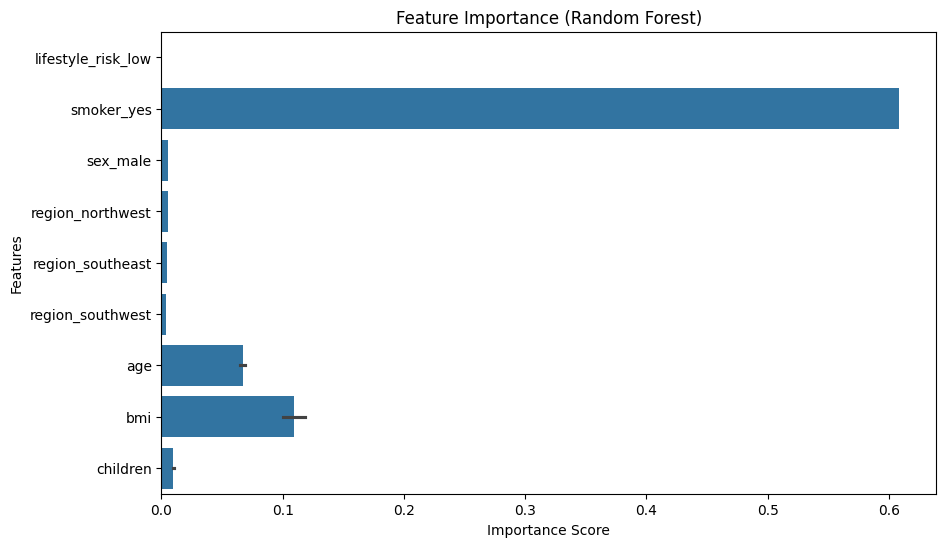

In [18]:

import matplotlib.pyplot as plt
import seaborn as sns

# Extracting feature names from the preprocessor
ohe_features = list(rf_pipeline.named_steps['preprocessor'].transformers_[0][1].get_feature_names_out(categorical_features))
all_features = ohe_features + numerical_features + numerical_features

# Get importances
importances = rf_pipeline.named_steps['regressor'].feature_importances_

# Create a plot
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=all_features)
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

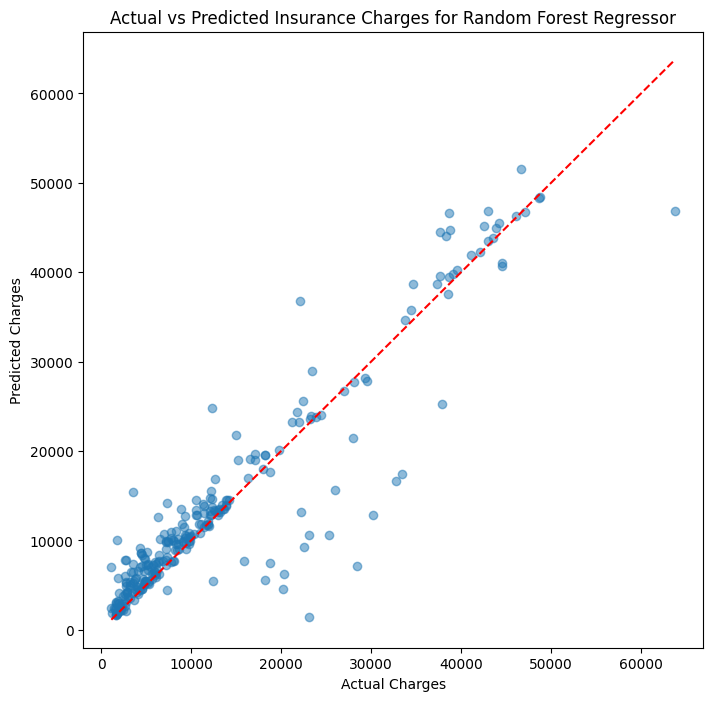

In [89]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, rf_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Insurance Charges for Random Forest Regressor')
plt.show()

In [21]:
import pickle
pickle_model_path = "model.pkl"
with open(pickle_model_path, 'wb') as f:
    pickle.dump(rf_pipeline, f)